## 1. Предобработка корпуса

* проводим лемматизацию и удаляем стоп-слова;
* приводем все леммы к нижнему регистру;
* добавляем частеречные теги.

Для предобработки мы будем использовать [*UDPipe*](https://ufal.mff.cuni.cz/udpipe)

In [2]:
pip install wget

Note: you may need to restart the kernel to use updated packages.


In [3]:
import wget
import sys

udpipe_url = 'https://rusvectores.org/static/models/udpipe_syntagrus.model'

modelfile = wget.download(udpipe_url)

Функция для предобработки текста

In [4]:
def process(pipeline, text='Строка', keep_pos=True, keep_punct=False):
    entities = {'PROPN'}
    named = False
    memory = []
    mem_case = None
    mem_number = None
    tagged_propn = []

    # обрабатываем текст, получаем результат в формате conllu:
    processed = pipeline.process(text)

    # пропускаем строки со служебной информацией:
    content = [l for l in processed.split('\n') if not l.startswith('#')]

    # извлекаем из обработанного текста леммы, тэги и морфологические характеристики
    tagged = [w.split('\t') for w in content if w]

    for t in tagged:
        if len(t) != 10:
            continue
        (word_id, token, lemma, pos, xpos, feats, head, deprel, deps, misc) = t
        if not lemma or not token:
            continue
        if pos in entities:
            if '|' not in feats:
                tagged_propn.append('%s_%s' % (lemma, pos))
                continue
            morph = {el.split('=')[0]: el.split('=')[1] for el in feats.split('|')}
            if 'Case' not in morph or 'Number' not in morph:
                tagged_propn.append('%s_%s' % (lemma, pos))
                continue
            if not named:
                named = True
                mem_case = morph['Case']
                mem_number = morph['Number']
            if morph['Case'] == mem_case and morph['Number'] == mem_number:
                memory.append(lemma)
                if 'SpacesAfter=\\n' in misc or 'SpacesAfter=\\s\\n' in misc:
                    named = False
                    past_lemma = '::'.join(memory)
                    memory = []
                    tagged_propn.append(past_lemma + '_PROPN ')
            else:
                named = False
                past_lemma = '::'.join(memory)
                memory = []
                tagged_propn.append(past_lemma + '_PROPN ')
                tagged_propn.append('%s_%s' % (lemma, pos))
        else:
            if not named:
                if pos == 'NUM' and token.isdigit():  # Заменяем числа на xxxxx той же длины
                    continue
                tagged_propn.append('%s_%s' % (lemma, pos))
            else:
                named = False
                past_lemma = '::'.join(memory)
                memory = []
                tagged_propn.append(past_lemma + '_PROPN ')
                tagged_propn.append('%s_%s' % (lemma, pos))

    if not keep_punct:
        tagged_propn = [word for word in tagged_propn if word.split('_')[1] != 'PUNCT']
    if not keep_pos:
        tagged_propn = [word.split('_')[0] for word in tagged_propn]
    return tagged_propn

print('ok')


ok


In [5]:
pip install ufal.udpipe

Note: you may need to restart the kernel to use updated packages.


In [6]:
from ufal.udpipe import Model, Pipeline
import os
import re

def tag_ud(text='Текст нужно передать функции в виде строки!', modelfile='udpipe_syntagrus.model'):
    cnt = 0
    udpipe_model_url = 'https://rusvectores.org/static/models/udpipe_syntagrus.model'
    udpipe_filename = udpipe_model_url.split('/')[-1]

    if not os.path.isfile(modelfile):
        print('UDPipe model not found. Downloading...', file=sys.stderr)
        wget.download(udpipe_model_url)

    print('\nLoading the model...', file=sys.stderr)
    model = Model.load(modelfile)
    process_pipeline = Pipeline(model, 'tokenize', Pipeline.DEFAULT, Pipeline.DEFAULT, 'conllu')

    print('Processing input...', file=sys.stderr)
    lines = text.split('\n')
    tagged = []
    for line in lines:
        # line = unify_sym(line.strip()) # здесь могла бы быть ваша функция очистки текста
        output = process(process_pipeline, text=line)
        tagged_line = ' '.join(output)
        tagged.append(tagged_line)
        cnt += 1
        if cnt%1000 == 0:
            print(cnt)
    return '\n'.join(tagged)

Приступаем непосредственно к предобработке нашего корпуса.

In [7]:
text = open(r'combined1.txt', 'r', encoding='utf-8').read()
processed_text = tag_ud(text=text, modelfile=modelfile)
print(processed_text[:350])
with open('combined1.txt', 'w', encoding='utf-8') as out:
    out.write(processed_text)


Loading the model...
Processing input...


1000
2000
3000
4000
5000
6000
7000
8000

d_x_propn_sym_PROPN \poem_corpus_1\_noun_PROPN _noun_propn_propn_PROPN poem_corpus_filtered_1.txt_x_propn_propn_PROPN
﻿_noun_propn_propn_PROPN ночь_propn_propn_propn_PROPN Посвещаться_verb_propn_propn_PROPN павлов_propn_noun_propn_PROPN ночь_propn_noun_propn_PROPN холодный_adj_noun_propn_PROPN воздух_noun_propn_propn_PROPN темнота_noun_propn_propn


In [8]:
pip install gensim

Note: you may need to restart the kernel to use updated packages.


In [9]:
import sys
import gensim, logging

logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

Одна строка - одно предложение

In [10]:
f = 'combined1.txt'
data = gensim.models.word2vec.LineSentence(f)

2. Приступаем к обучению моделей

2.1 CBOW

Инициализируем модель. Параметры в скобочках:
* data - данные,
* size - размер вектора,
* window - размер окна наблюдения,
* min_count - мин. частотность слова в корпусе, которое мы берем,
* sg - используемый алгоритм обучение (0 - CBOW, 1 - Skip-gram))

In [11]:
model_CBOW = gensim.models.Word2Vec(data, vector_size=500, window=5, min_count=2, sg=0)

2025-06-16 18:21:37,237 : INFO : collecting all words and their counts
2025-06-16 18:21:37,243 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2025-06-16 18:21:37,567 : INFO : collected 103448 word types from a corpus of 939393 raw words and 7980 sentences
2025-06-16 18:21:37,567 : INFO : Creating a fresh vocabulary
2025-06-16 18:21:37,660 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=2 retains 35094 unique words (33.92% of original 103448, drops 68354)', 'datetime': '2025-06-16T18:21:37.660090', 'gensim': '4.3.3', 'python': '3.10.0 (tags/v3.10.0:b494f59, Oct  4 2021, 19:00:18) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26100-SP0', 'event': 'prepare_vocab'}
2025-06-16 18:21:37,660 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=2 leaves 871039 word corpus (92.72% of original 939393, drops 68354)', 'datetime': '2025-06-16T18:21:37.660090', 'gensim': '4.3.3', 'python': '3.10.0 (tags/v3.10.0:b494f59, Oct  4 2021, 1

Сколько слов в модели?

In [12]:
print(len(model_CBOW.wv.key_to_index))


35094


Сохраняем модель

In [13]:
model_CBOW.save('cbow_poem.model')

2025-06-16 18:21:43,000 : INFO : Word2Vec lifecycle event {'fname_or_handle': 'cbow_poem.model', 'separately': 'None', 'sep_limit': 10485760, 'ignore': frozenset(), 'datetime': '2025-06-16T18:21:43.000355', 'gensim': '4.3.3', 'python': '3.10.0 (tags/v3.10.0:b494f59, Oct  4 2021, 19:00:18) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26100-SP0', 'event': 'saving'}
2025-06-16 18:21:43,006 : INFO : storing np array 'vectors' to cbow_poem.model.wv.vectors.npy
2025-06-16 18:21:43,117 : INFO : storing np array 'syn1neg' to cbow_poem.model.syn1neg.npy
2025-06-16 18:21:43,229 : INFO : not storing attribute cum_table
2025-06-16 18:21:43,245 : INFO : saved cbow_poem.model


Загружаем сохраненную модель

In [14]:
from gensim.models import Word2Vec
cbow = Word2Vec.load('cbow_poem.model')

2025-06-16 18:21:43,254 : INFO : loading Word2Vec object from cbow_poem.model
2025-06-16 18:21:43,278 : INFO : loading wv recursively from cbow_poem.model.wv.* with mmap=None
2025-06-16 18:21:43,278 : INFO : loading vectors from cbow_poem.model.wv.vectors.npy with mmap=None
2025-06-16 18:21:43,302 : INFO : loading syn1neg from cbow_poem.model.syn1neg.npy with mmap=None
2025-06-16 18:21:43,335 : INFO : setting ignored attribute cum_table to None
2025-06-16 18:21:43,491 : INFO : Word2Vec lifecycle event {'fname': 'cbow_poem.model', 'datetime': '2025-06-16T18:21:43.491124', 'gensim': '4.3.3', 'python': '3.10.0 (tags/v3.10.0:b494f59, Oct  4 2021, 19:00:18) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26100-SP0', 'event': 'loaded'}


Косинусное сходство

In [15]:
print(list(cbow.wv.key_to_index.keys())[:20])

['и_cconj_noun_propn_PROPN', 'в_adp_propn_propn_PROPN', 'я_pron_propn_propn_PROPN', 'не_part_propn_propn_PROPN', 'ты_pron_propn_propn_PROPN', 'на_adp_propn_propn_PROPN', 'с_adp_propn_propn_PROPN', 'он_pron_propn_propn_PROPN', 'мы_pron_propn_propn_PROPN', 'а_cconj_noun_propn_PROPN', 'что_pron_propn_propn_PROPN', 'как_sconj_noun_propn_PROPN', 'быть_aux_propn_propn_PROPN', 'но_cconj_noun_propn_PROPN', 'она_pron_propn_propn_PROPN', 'мой_det_propn_propn_PROPN', 'что_sconj_noun_propn_PROPN', 'они_pron_propn_propn_PROPN', 'весь_det_propn_propn_PROPN', 'к_adp_propn_propn_PROPN']


In [24]:
cbow.wv.similarity("быть_aux_propn_propn_PROPN", "спать_verb_propn_propn_PROPN")

0.8138316

In [27]:
cbow.wv.similarity("холодный_adj_noun_propn_PROPN", "другой_adj_noun_propn_PROPN")

0.33532614

In [29]:
cbow.wv.similarity("жизнь_noun_propn_propn_PROPN", "любовь_noun_propn_propn_PROPN")

0.77190334

In [30]:
for t in cbow.wv.most_similar(positive=[u'любовь_noun_propn_propn_PROPN'], topn=20):
    print (t[0], t[1])

чувство_noun_propn_propn_PROPN 0.9400321841239929
любовь_propn_propn_propn_PROPN 0.9378575086593628
мечта_noun_propn_propn_PROPN 0.9232890009880066
сожжение_noun_propn_propn_PROPN 0.9220795035362244
счастье_noun_propn_propn_PROPN 0.9197050333023071
ошибка_propn_propn_propn_PROPN 0.9161195755004883
душа_noun_propn_propn_PROPN 0.9042963981628418
радость_noun_propn_propn_PROPN 0.9031909108161926
нечего_noun_propn_propn_PROPN 0.9025272130966187
боль_noun_propn_propn_PROPN 0.8970008492469788
страх_noun_propn_propn_PROPN 0.895645260810852
сердце_noun_propn_propn_PROPN 0.8948795199394226
надежда_noun_propn_propn_PROPN 0.8947373628616333
добрый_adj_noun_x_PROPN 0.8937760591506958
слово_noun_propn_propn_PROPN 0.8929337859153748
пригодный_adj_noun_propn_PROPN 0.8828231692314148
придть_verb_propn_propn_PROPN 0.8811425566673279
теплокоммуникация_noun_propn_propn_PROPN 0.8804544806480408
вальс_propn_propn_propn_PROPN 0.8765469789505005
любимый_adj_noun_propn_PROPN 0.8740978240966797


Евклидово расстояние

In [31]:
import numpy as np

euclid1 = np.linalg.norm(cbow.wv['жизнь_noun_propn_propn_PROPN'] - cbow.wv['любовь_noun_propn_propn_PROPN'])
euclid2 = np.linalg.norm(cbow.wv['жизнь_noun_propn_propn_PROPN'] - cbow.wv['страх_noun_propn_propn_PROPN'])
print(euclid1, euclid2)

5.7008576 4.6201406


## 2.2 Skip-Gram

In [32]:
model_sg = gensim.models.Word2Vec(data, vector_size=500, window=5, min_count=2, sg=1)

2025-06-16 18:29:35,117 : INFO : collecting all words and their counts
2025-06-16 18:29:35,117 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2025-06-16 18:29:35,414 : INFO : collected 103448 word types from a corpus of 939393 raw words and 7980 sentences
2025-06-16 18:29:35,414 : INFO : Creating a fresh vocabulary
2025-06-16 18:29:35,508 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=2 retains 35094 unique words (33.92% of original 103448, drops 68354)', 'datetime': '2025-06-16T18:29:35.508927', 'gensim': '4.3.3', 'python': '3.10.0 (tags/v3.10.0:b494f59, Oct  4 2021, 19:00:18) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26100-SP0', 'event': 'prepare_vocab'}
2025-06-16 18:29:35,508 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=2 leaves 871039 word corpus (92.72% of original 939393, drops 68354)', 'datetime': '2025-06-16T18:29:35.508927', 'gensim': '4.3.3', 'python': '3.10.0 (tags/v3.10.0:b494f59, Oct  4 2021, 1

In [33]:
model_sg.save('skip-gram_poem.model')

2025-06-16 18:30:00,742 : INFO : Word2Vec lifecycle event {'fname_or_handle': 'skip-gram_poem.model', 'separately': 'None', 'sep_limit': 10485760, 'ignore': frozenset(), 'datetime': '2025-06-16T18:30:00.742312', 'gensim': '4.3.3', 'python': '3.10.0 (tags/v3.10.0:b494f59, Oct  4 2021, 19:00:18) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26100-SP0', 'event': 'saving'}
2025-06-16 18:30:00,743 : INFO : storing np array 'vectors' to skip-gram_poem.model.wv.vectors.npy
2025-06-16 18:30:00,781 : INFO : storing np array 'syn1neg' to skip-gram_poem.model.syn1neg.npy
2025-06-16 18:30:00,844 : INFO : not storing attribute cum_table
2025-06-16 18:30:00,862 : INFO : saved skip-gram_poem.model


In [34]:
from gensim.models import Word2Vec
sg = Word2Vec.load('skip-gram_poem.model')

2025-06-16 18:30:02,990 : INFO : loading Word2Vec object from skip-gram_poem.model
2025-06-16 18:30:03,013 : INFO : loading wv recursively from skip-gram_poem.model.wv.* with mmap=None
2025-06-16 18:30:03,015 : INFO : loading vectors from skip-gram_poem.model.wv.vectors.npy with mmap=None
2025-06-16 18:30:03,057 : INFO : loading syn1neg from skip-gram_poem.model.syn1neg.npy with mmap=None
2025-06-16 18:30:03,089 : INFO : setting ignored attribute cum_table to None
2025-06-16 18:30:03,250 : INFO : Word2Vec lifecycle event {'fname': 'skip-gram_poem.model', 'datetime': '2025-06-16T18:30:03.250729', 'gensim': '4.3.3', 'python': '3.10.0 (tags/v3.10.0:b494f59, Oct  4 2021, 19:00:18) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26100-SP0', 'event': 'loaded'}


In [36]:
for t in sg.wv.most_similar(positive=[u'страх_noun_propn_propn_PROPN'], topn=20):
    print (t[0], t[1])

стыд_noun_propn_propn_PROPN 0.8745952248573303
ревность_noun_propn_propn_PROPN 0.850387454032898
сомненье_noun_propn_propn_PROPN 0.848906934261322
ужас_noun_propn_propn_PROPN 0.834428608417511
сомнение_noun_propn_propn_PROPN 0.8338715434074402
обида_noun_propn_propn_PROPN 0.8318343758583069
задыхаться_verb_propn_propn_PROPN 0.8314266204833984
ненависть_noun_propn_propn_PROPN 0.8313111662864685
злость_noun_propn_propn_PROPN 0.8298724889755249
жалость_noun_propn_propn_PROPN 0.8290982842445374
тяжкий_adj_noun_propn_PROPN 0.8264224529266357
злоба_noun_propn_propn_PROPN 0.8250356316566467
боль_noun_propn_propn_PROPN 0.8247672915458679
страдание_noun_propn_propn_PROPN 0.8237114548683167
фальшь_noun_propn_propn_PROPN 0.8218112587928772
боль_propn_propn_propn_PROPN 0.8214356303215027
заставлять_verb_propn_propn_PROPN 0.8211540579795837
потеря_noun_propn_propn_PROPN 0.8205191493034363
утрата_noun_propn_propn_PROPN 0.8181117177009583
усталость_noun_propn_propn_PROPN 0.8153852224349976


In [37]:
sg.wv.similarity("думать_verb_propn_propn_PROPN", "спать_verb_propn_propn_PROPN")

0.5446028

In [38]:
sg.wv.similarity("холодный_adj_noun_propn_PROPN", "другой_adj_noun_propn_PROPN")

0.47246644

In [39]:
sg.wv.similarity("жизнь_noun_propn_propn_PROPN", "любовь_noun_propn_propn_PROPN")

0.6081777

In [40]:
euclid3 = np.linalg.norm(sg.wv['жизнь_noun_propn_propn_PROPN'] - sg.wv['любовь_noun_propn_propn_PROPN'])  
euclid4 = np.linalg.norm(sg.wv['жизнь_noun_propn_propn_PROPN'] - sg.wv['страх_noun_propn_propn_PROPN'])
print(euclid3, euclid4)

2.8600538 2.6922483


## Коллокаты

In [41]:
import re

for t in sg.wv.most_similar(positive=[u'жизнь_noun_propn_propn_PROPN'], topn=10):
  cond = re.search(r'_(NOUN)|(ADJ)|(NUM)', t[0])
  if cond != None:
    print (t[0], t[1])

In [42]:
import re

for t in cbow.wv.most_similar(positive=[u'жизнь_noun_propn_propn_PROPN'], topn=10):
  cond = re.search(r'_(NOUN)|(ADJ)|(NUM)', t[0])
  if cond != None:
    print (t[0], t[1])

In [43]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [44]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [45]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [46]:
pip install scikit-learn

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/10.7 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/10.7 MB 9.6 MB/s eta 0:00:01
   ----------- ---------------------------- 3.1/10.7 MB 10.9 MB/s eta 0:00:01
   ----------------------- ---------------- 6.3/10.7 MB 11.4 MB/s eta 0:00:01
   ------------------------------- -------- 8.4/10.7 MB 11.6 MB/s eta 0:00:01
   ---------------------------------------- 10.7/10.7 MB 11.2 MB/s eta 0:00:00
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ----------

2025-06-16 18:35:44,801 : INFO : loading Word2Vec object from skip-gram_poem.model
2025-06-16 18:35:44,819 : INFO : loading wv recursively from skip-gram_poem.model.wv.* with mmap=None
2025-06-16 18:35:44,820 : INFO : loading vectors from skip-gram_poem.model.wv.vectors.npy with mmap=None
2025-06-16 18:35:44,852 : INFO : loading syn1neg from skip-gram_poem.model.syn1neg.npy with mmap=None
2025-06-16 18:35:44,870 : INFO : setting ignored attribute cum_table to None
2025-06-16 18:35:45,016 : INFO : Word2Vec lifecycle event {'fname': 'skip-gram_poem.model', 'datetime': '2025-06-16T18:35:45.015922', 'gensim': '4.3.3', 'python': '3.10.0 (tags/v3.10.0:b494f59, Oct  4 2021, 19:00:18) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26100-SP0', 'event': 'loaded'}


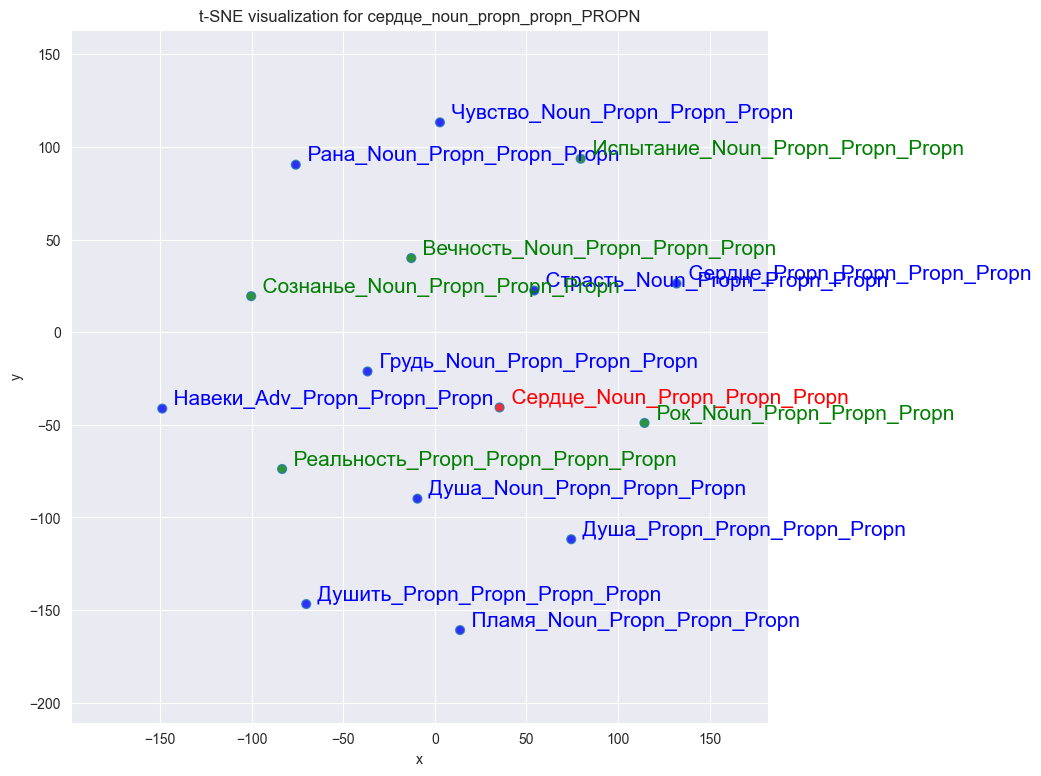

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

sns.set_style("darkgrid")

# Загружаем модель Word2Vec
from gensim.models import Word2Vec
model = Word2Vec.load("skip-gram_poem.model")  # Укажи путь к своей модели

def tsnescatterplot(model, word, list_names):
    # Используем размерность вектора из модели
    arrays = np.empty((0, model.wv.vector_size), dtype='f')
    word_labels = [word]
    color_list = ['red']

    # Добавляем вектор целевого слова
    arrays = np.append(arrays, model.wv.__getitem__([word]), axis=0)

    # Получаем семантические ассоциаты
    close_words = model.wv.most_similar([word])

    for wrd_score in close_words:
        wrd_vector = model.wv.__getitem__([wrd_score[0]])
        word_labels.append(wrd_score[0])
        color_list.append('blue')
        arrays = np.append(arrays, wrd_vector, axis=0)

    for wrd in list_names:
        wrd_vector = model.wv.__getitem__([wrd])
        word_labels.append(wrd)
        color_list.append('green')
        arrays = np.append(arrays, wrd_vector, axis=0)

    reduc = PCA(n_components=4).fit_transform(arrays)
    Y = TSNE(n_components=2, random_state=0, perplexity=15).fit_transform(reduc)

    df = pd.DataFrame({'x': [x for x in Y[:, 0]],
                       'y': [y for y in Y[:, 1]],
                       'words': word_labels,
                       'color': color_list})

    fig, _ = plt.subplots()
    fig.set_size_inches(9, 9)

    p1 = sns.regplot(data=df,
                     x="x",
                     y="y",
                     fit_reg=False,
                     marker="o",
                     scatter_kws={'s': 40,
                                  'facecolors': df['color']
                                  })

    for line in range(0, df.shape[0]):
        p1.text(df["x"][line],
                df['y'][line],
                '  ' + df["words"][line].title(),
                horizontalalignment='left',
                verticalalignment='bottom', size='medium',
                color=df['color'][line],
                weight='normal'
                ).set_size(15)

    plt.xlim(Y[:, 0].min() - 50, Y[:, 0].max() + 50)
    plt.ylim(Y[:, 1].min() - 50, Y[:, 1].max() + 50)
    plt.title('t-SNE visualization for {}'.format(word))
    plt.show()
    return None  

tsnescatterplot(model, 'сердце_noun_propn_propn_PROPN', [t[0] for t in model.wv.most_similar(positive=["жизнь_noun_propn_propn_PROPN"], topn=10)][5:])


## Оценка
Судя по оценкам (евклидово расстояние и косинусное расстояние) для подбора синонимов модель CBOW работает лучше, чем Skip-Gram.

Но Skip-Gram лучше определяет сходство между несинонимичными парами